# AC Power Flow with HELIOS: A Six-Bus Microgrid

This notebook is a hands-on tour of **[HELIOS](https://stepss.sps-lab.org/python/helios/)**,
the AC power-flow engine of the [STEPSS](https://stepss.sps-lab.org) platform, on a system
small enough to check every number by hand.

We load the case, solve it, read the solution back, render the one-line diagram, stress the
network until it stops converging, and run an N-1 contingency screen. The last of those
turns up a result that looks clean and is not, which is the most useful thing in this
notebook.

**Installation** (needed only if you are not on the course JupyterHub):

```bash
pip install jupyter ipython stepss
```

On Linux the engine additionally needs `libopenblas0 libgfortran5 libgomp1`
(see the [installation guide](https://stepss.sps-lab.org/python/installation/)).

## The system

A six-bus microgrid at two voltage levels:

- **Buses A, D, E, F at 6 kV** and **B, C at 11 kV**;
- **two lines**, `B-C` and `D-E`, and **four transformers**, `D-B`, `E-C`, `A-B`, `F-B`;
- **two loads**, 1 MW + 0.3 Mvar at D and 4 MW + 1.2 Mvar at E;
- **two generators**: `A` is the **slack**, and `F` is fixed at 2 MW.

The whole model is 30 lines of `6bus.dat`. This is a **power-flow-only** case: the
repository carries no dynamic data and no disturbance file, so nothing here goes near
RAMSES.

| File | Contents |
|------|----------|
| `6bus.dat` | Solver tolerances, 6 buses, 2 lines, 4 transformers, 2 generators, slack definition |
| `volt_rat.dat` | The solved bus voltages as `LFRESV` records, as written by the HELIOS `VT` command |
| `6bus.svg` | One-line diagram **template**, with `%A` to `%U` placeholders that HELIOS substitutes with solved values |

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import stepss
from stepss.helios import HeliosSession

print('stepss', stepss.__version__)

stepss 3.70


In [2]:
plt.rcParams.update({
    'figure.figsize': (9, 4.2), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'lines.linewidth': 1.8, 'font.size': 11, 'legend.frameon': False,
})
COL_1 = '#2a78d6'   # blue
COL_2 = '#eb6834'   # orange
COL_3 = '#1baf7a'   # aqua
COL_4 = '#eda100'   # yellow

## Loading and solving

A `HeliosSession` is also a context manager (`with HeliosSession() as pf:`). Here we keep it
open across cells.

In [3]:
pf = HeliosSession()
print(pf.build_info())

pf.load_file('6bus.dat')
converged = pf.solve()
print(f'converged: {converged} in {pf.iterations} iteration(s), '
      f'largest mismatch {max(pf.max_mismatch):.4f} MVA')
print(f'{pf.bus_count} buses, {pf.branch_count} branches, {pf.generator_count} generators')

helios 1.4.1 (GNU, Linux)
converged: True in 3 iteration(s), largest mismatch 0.0029 MVA
6 buses, 6 branches, 2 generators


Three iterations of Newton-Raphson from a flat start. `max_mismatch` is a per-iteration
history, so `max(...)` is the worst residual seen anywhere in the solve.

### The solved operating point

In [4]:
print(f'{"bus":>4} {"Vnom":>6} {"V [pu]":>8} {"angle":>8} {"P load":>8} {"Q load":>8}  type')
for b in pf.bus_names():
    i = pf.get_bus_info(b)
    print(f'{i.name:>4} {i.vnom_kv:5.0f}k {i.v_pu:8.4f} {np.degrees(i.angle_rad):7.2f}d '
          f'{i.p_load_mw:8.2f} {i.q_load_mvar:8.2f}  {i.bus_type}')

p_load, q_load = pf.get_bus_loads()
p_gen, q_gen, _ = pf.get_generator_outputs()
print(f'\ntotal load       : {p_load.sum():7.3f} MW  {q_load.sum():7.3f} Mvar')
print(f'total generation : {p_gen.sum():7.3f} MW  {q_gen.sum():7.3f} Mvar')
print(f'network losses   : {p_gen.sum() - p_load.sum():7.3f} MW  '
      f'({100 * (p_gen.sum() - p_load.sum()) / p_load.sum():.1f} % of load)')

 bus   Vnom   V [pu]    angle   P load   Q load  type
   A     6k   1.0000    0.00d     0.00     0.00  2
   B    11k   0.9801   -3.55d     0.00     0.00  0
   C    11k   0.9736   -3.58d     0.00     0.00  0
   D     6k   0.9657   -6.54d     1.00     0.30  0
   E     6k   0.9538   -6.72d     4.00     1.20  0
   F     6k   1.0000   -1.21d     0.00     0.00  1

total load       :   5.000 MW    1.500 Mvar
total generation :   5.033 MW    2.121 Mvar
network losses   :   0.033 MW  (0.7 % of load)


Bus A holds 1.0 pu because it is the slack, and F holds 1.0 pu because it is a voltage-
controlled generator bus. Everything else sags away from those two points, with **E the
weakest bus** at the far end of the 6 kV feeder behind both a transformer and a line.

### Branch flows

Where the power actually goes:

In [5]:
print(f'{"branch":>7} {"from":>5} {"to":>4} {"P from":>9} {"Q from":>9} {"P to":>9} '
      f'{"loss":>8} {"Snom":>7}  kind')
tot = 0.0
for br in pf.branch_names():
    i = pf.get_branch_info(br)
    loss = i.p_from_mw + i.p_to_mw          # to-end is signed into the branch
    tot += loss
    kind = 'transformer' if i.is_transformer else 'line'
    print(f'{i.name:>7} {i.from_bus:>5} {i.to_bus:>4} {i.p_from_mw:9.3f} {i.q_from_mvar:9.3f} '
          f'{i.p_to_mw:9.3f} {loss:8.4f} {i.snom_mva:7.1f}  {kind}')
print(f'\nsum of branch losses: {tot:.4f} MW')

 branch  from   to    P from    Q from      P to     loss    Snom  kind
    B-C     B    C     2.562     1.039    -2.546   0.0164     5.0  line
    D-E     D    E     1.471     0.335    -1.454   0.0169     5.0  line
    D-B     D    B    -2.469    -0.634     2.469   0.0000     5.0  transformer
    E-C     E    C    -2.544    -0.873     2.544   0.0000     5.0  transformer
    A-B     A    B     3.033     1.087    -3.033   0.0000     5.0  transformer
    F-B     F    B     2.000     1.034    -2.000   0.0000     5.0  transformer

sum of branch losses: 0.0334 MW


The sum of the individual branch losses reproduces the generation-minus-load figure above,
which is the arithmetic check worth doing on any power-flow result you did not solve
yourself.

### The one-line diagram

`6bus.svg` is a template full of `%A` to `%U` placeholder codes. `write_diagram()` fills them
with the solved values, which is what the `1` command does in the interactive HELIOS shell.

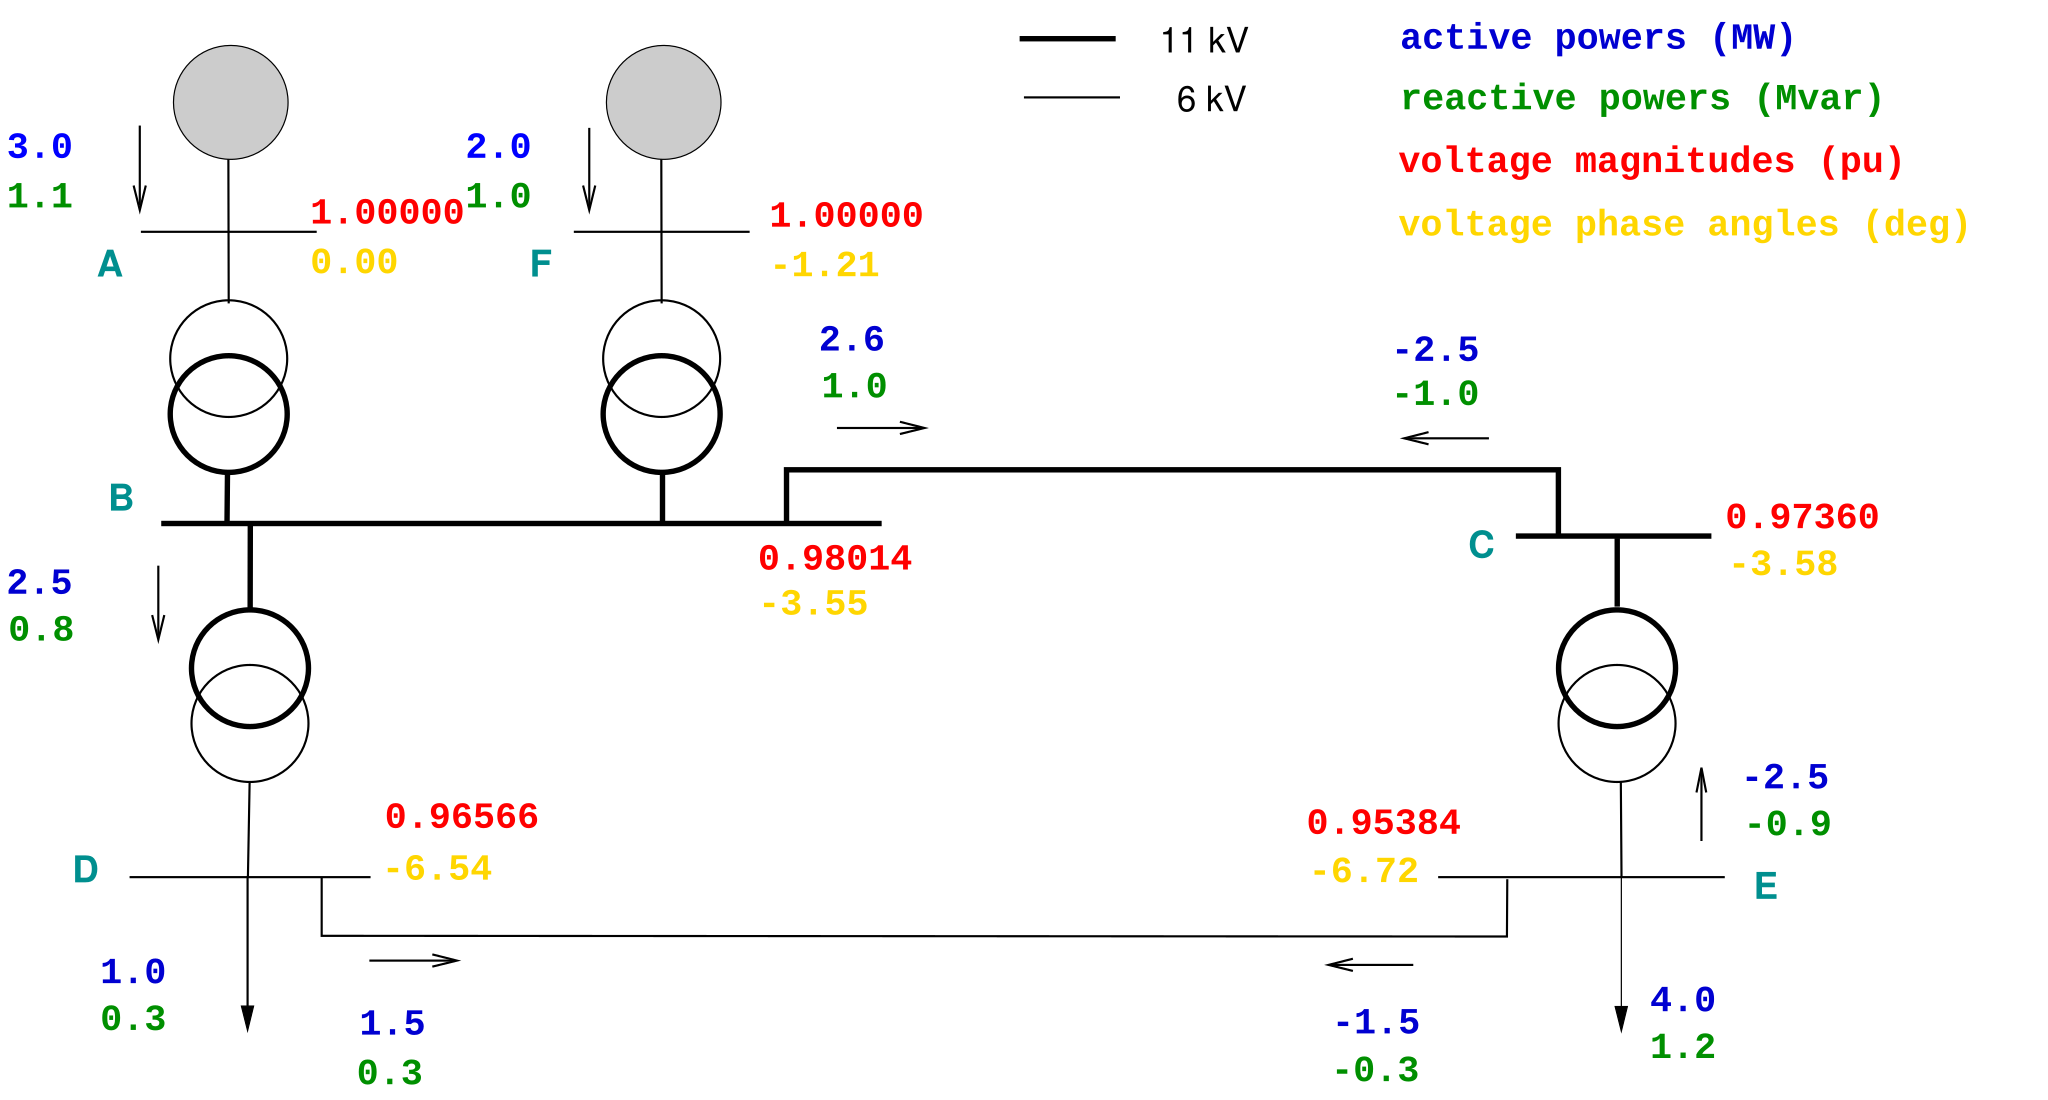

In [6]:
from IPython.display import SVG, display

pf.write_diagram('6bus.svg', 'solved_diagram.svg')
display(SVG(filename='solved_diagram.svg'))

## Stressing the network

`set_load()` takes **absolute** targets, and `apply_changes()` re-runs the solver. We walk
the load at bus E up in steps and watch the voltages fall, which traces the upper branch of
a PV curve.

In [7]:
base = pf.get_bus_info('E')
print(f'base load at E: {base.p_load_mw:.2f} MW + {base.q_load_mvar:.2f} Mvar')

pf_factor = base.q_load_mvar / base.p_load_mw     # hold power factor constant
rows = []
for p in np.arange(base.p_load_mw, 14.01, 0.5):
    pf.set_load('E', float(p), float(p * pf_factor))
    ok = pf.apply_changes()
    if not ok:
        print(f'power flow failed to converge at P(E) = {p:.1f} MW')
        break
    rows.append((p, pf.get_bus_voltage('E')[0], pf.get_bus_voltage('D')[0],
                 pf.get_generator_info('A').p_mw))
    last_p = p

print(f'last converged point: P(E) = {rows[-1][0]:.1f} MW, V(E) = {rows[-1][1]:.4f} pu')

base load at E: 4.00 MW + 1.20 Mvar
last converged point: P(E) = 14.0 MW, V(E) = 0.7278 pu


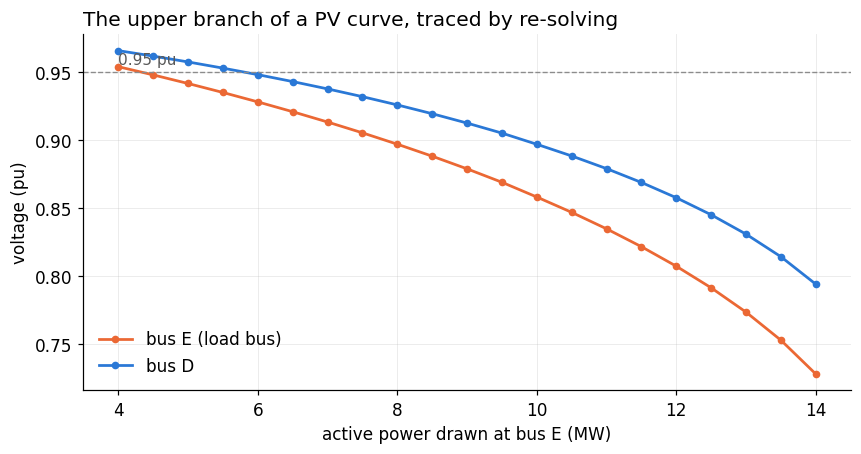

In [8]:
rows = np.array(rows)
fig, ax = plt.subplots()
ax.plot(rows[:, 0], rows[:, 1], marker='o', markersize=4, color=COL_2, label='bus E (load bus)')
ax.plot(rows[:, 0], rows[:, 2], marker='o', markersize=4, color=COL_1, label='bus D')
ax.axhline(0.95, color='0.55', linewidth=0.9, linestyle='--')
ax.annotate('0.95 pu', (rows[0, 0], 0.95), xytext=(0, 5), textcoords='offset points',
            color='0.35', fontsize=10)
ax.set_xlabel('active power drawn at bus E (MW)')
ax.set_ylabel('voltage (pu)')
ax.set_title('The upper branch of a PV curve, traced by re-solving', loc='left')
ax.legend(loc='lower left')
plt.show()

The curve bends over as the load grows: this is the classic PV, or nose, curve, and the
point where the solver stops converging is close to the maximum power the network can
deliver to that bus. Note the voltage passes below 0.95 pu long before the nose, which is
the practical limit an operator would respect.

Now put the case back where it started.

In [9]:
pf.set_load('E', base.p_load_mw, base.q_load_mvar)
assert pf.apply_changes()
print(f'restored: V(E) = {pf.get_bus_voltage("E")[0]:.4f} pu, '
      f'P load total = {pf.get_bus_loads()[0].sum():.2f} MW')

restored: V(E) = 0.9538 pu, P load total = 5.00 MW


## N-1 contingency screening, and a trap

`run_contingencies(branches=True)` opens each in-service branch in turn, re-solves, and
checks the result against a voltage band and a loading threshold. The base case is restored
afterwards.

In [10]:
results = pf.run_contingencies(branches=True, v_min=0.95, v_max=1.05, overload=100.0)

print(f'{"contingency":>14} {"conv":>5} {"ok":>4} {"Vmin":>8} {"at":>4} '
      f'{"max load %":>11} {"violations":>11}')
for r in results:
    print(f'{r.name:>14} {str(r.converged):>5} {str(r.accepted):>4} {r.min_v_pu:8.4f} '
          f'{r.min_v_bus:>4} {r.max_loading_pct:11.1f} {len(r.violations):11d}')

   contingency  conv   ok     Vmin   at  max load %  violations
       BR: B-C  True False   0.9002    E       112.2           4
       BR: D-E  True False   0.9392    E        87.0           1
       BR: D-B  True False   0.9158    D       110.4           4
       BR: E-C  True False   0.9000    E       112.3           3
       BR: A-B  True True   1.0000    A         0.0           0
       BR: F-B  True False   0.9290    E       112.1           4


Five of the six contingencies are rejected, which is unsurprising for a small radial
microgrid with no redundancy. The interesting row is **`BR: A-B`**, the only one reported as
*accepted*, with a minimum voltage of exactly 1.0000 pu and zero branch loading.

That is not a healthy network. It is an empty one:

In [11]:
pf.trip_branch('A-B')
pf.apply_changes()
print('bus voltages after opening A-B:')
for b in pf.bus_names():
    print(f'  {b}: {pf.get_bus_voltage(b)[0]:.4f} pu')
print('\ngeneration:', {g: round(pf.get_generator_info(g).p_mw, 2) for g in pf.generator_names()})

# Re-closing the branch is NOT enough to bring the network back: see the note below.
pf.connect_branch('A-B')
print('after connect_branch + apply_changes: V(E) =',
      f'{(pf.apply_changes(), pf.get_bus_voltage("E")[0])[1]:.4f} pu')

pf.reset()          # restore the state saved at load_file()
pf.solve()
print(f'after reset + solve            : V(E) = {pf.get_bus_voltage("E")[0]:.4f} pu')

bus voltages after opening A-B:
  A: 1.0000 pu
  B: 0.0000 pu
  C: 0.0000 pu
  D: 0.0000 pu
  E: 0.0000 pu
  F: 0.0000 pu

generation: {'A': 0.0, 'F': 2.0}
after connect_branch + apply_changes: V(E) = 0.0000 pu
after reset + solve            : V(E) = 0.9538 pu


`A-B` is the transformer that connects the **slack bus** to the rest of the network. Opening
it splits the system into the slack bus on one side and everything else on the other. The
five de-energised buses solve to 0 pu, and the screening evaluates only the island that
still has the slack in it: one bus, at its set-point, with nothing connected. No voltage
violations, no overloads, "accepted".

**The lesson generalises well beyond this toy case.** A contingency screen answers the
question you asked, which was about voltages and loadings, not the question you meant, which
was whether the system survives. Always check connectivity alongside the acceptance flag.

Note the second surprise in the cell above. Once the network is de-energised,
**`connect_branch()` does not bring it back**: `apply_changes()` reports convergence, but it
converges to the all-zero solution, which is a perfectly valid fixed point of the power-flow
equations when the solver starts from a collapsed state. Restoring the case needs
`reset()`, which returns to the state saved at `load_file()`, followed by a fresh `solve()`.
The helper below therefore resets between contingencies rather than trying to undo them.

In [12]:
def screen(pf, **kw):
    """N-1 screening that also reports how much load each contingency de-energises."""
    pf.reset()
    pf.solve()
    verdicts = {r.name.split(':')[-1].strip(): r for r in pf.run_contingencies(branches=True, **kw)}
    loads = {b: pf.get_bus_info(b).p_load_mw for b in pf.bus_names()}

    out = []
    for name, r in verdicts.items():
        pf.reset()                      # always start each trial from the saved base case
        pf.solve()
        pf.trip_branch(name)
        pf.apply_changes()
        v, _ = pf.get_bus_voltages()
        dark = [b for b, val in zip(pf.bus_names(), v) if val < 0.1]
        out.append((name, r.accepted, len(r.violations), dark, sum(loads[b] for b in dark)))
    pf.reset()
    pf.solve()
    return out


print(f'{"branch":>7} {"accepted":>9} {"viol":>5} {"de-energised":>14} {"load lost":>11}')
for name, acc, nv, dark, lost in screen(pf, v_min=0.95, v_max=1.05):
    flag = '  <-- blackout' if lost > 0 else ''
    print(f'{name:>7} {str(acc):>9} {nv:5d} {",".join(dark) if dark else "-":>14} '
          f'{lost:8.2f} MW{flag}')

 branch  accepted  viol   de-energised   load lost
    B-C     False     4              -     0.00 MW
    D-E     False     1              -     0.00 MW
    D-B     False     4              -     0.00 MW
    E-C     False     3              -     0.00 MW
    A-B      True     0      B,C,D,E,F     5.00 MW  <-- blackout
    F-B     False     4              F     0.00 MW


Now the ranking is honest: the one contingency the plain screen called acceptable is the
only one that turns the lights off, and it costs the entire 5 MW of load.

## Exporting the solution

Two exports, for two different consumers:

In [13]:
pf.write_dump('6bus_solved.dat')        # a complete, re-loadable static case
pf.write_voltrat('volt_rat_check.dat')  # LFRESV records: initial conditions for RAMSES

with open('volt_rat_check.dat') as f:
    written = f.read()
print(written)
print('distributed volt_rat.dat, for comparison:\n')
print(open('volt_rat.dat').read())

LFRESV A        1.0000000  0.00000000e+00 ;
LFRESV B        0.9801377 -6.19245147e-02 ;
LFRESV C        0.9735982 -6.25596268e-02 ;
LFRESV D        0.9656645 -1.14128349e-01 ;
LFRESV E        0.9538407 -1.17365274e-01 ;
LFRESV F        1.0000000 -2.11066558e-02 ;

distributed volt_rat.dat, for comparison:

LFRESV A        1.0000000  0.00000000E+00 ;
LFRESV B        0.9801377 -0.61924515E-01 ;
LFRESV C        0.9735982 -0.62559627E-01 ;
LFRESV D        0.9656645 -0.11412835E+00 ;
LFRESV E        0.9538407 -0.11736527E+00 ;
LFRESV F        1.0000000 -0.21106656E-01 ;



The regenerated file reproduces the distributed `volt_rat.dat` to every printed digit, which
is the check that the solver, the case and the stored solution all still agree.

`write_voltrat()` output is the input RAMSES initialises from, but **this repository has no
dynamic data**: no `SYNC_MACH`, no `EXC`, no `TOR`, no disturbance file. To carry this
microgrid into a dynamic study you would have to write those yourself. The
[Kundur two-area system](https://github.com/SPS-L/stepss-Kundur-Two-Area-System) and the
[Cyprus transmission model](https://github.com/SPS-L/stepss-Cyprus-TN-Dynamic-Model) in this
collection show what that data looks like.

In [14]:
pf.close()
print('session closed')

session closed


## What you have seen

- The **load, solve, query, modify, re-solve** lifecycle of `HeliosSession`, with
  `set_load()` taking absolute targets and `apply_changes()` re-running the solver.
- A **PV curve traced by continuation**, and the difference between the voltage limit an
  operator respects and the point where the solver gives up.
- `write_diagram()` filling a template SVG with solved values, and `write_dump()` /
  `write_voltrat()` writing the two export formats.
- An **automated N-1 screen reporting a blackout as acceptable**, because a screen checks
  the quantities you name and cannot know that "no violations on the energised island" is
  the wrong question. Checking connectivity is cheap; assuming it is not.

### Things to try

- **Move the slack.** Change the `SLACK` record to bus F and re-run the screen. Which
  contingency becomes the deceptive one now?
- **Add redundancy.** Duplicate the `A-B` transformer record under a new name and see the
  screen turn green.
- **Sweep both loads.** Extend the PV curve study to raise D and E together and find the
  loadability limit of the microgrid as a whole.
- **Compare against `run_contingencies(generators=True)`**, which trips generators instead of
  branches. With only two generators, one of them the slack, what should you expect?

### References

- [HELIOS Python guide](https://stepss.sps-lab.org/python/helios/) and the
  [stepss API reference](https://stepss.sps-lab.org/python/)
- [STEPSS user guide, power-flow data formats](https://stepss.sps-lab.org/user-guide/power-flow/)